# Transformer 챗봇 만들기

학습 목표

챗봇 훈련 데이터 전처리 과정이 체계적으로 진행되었는가?

transformer 모델을 활용한 챗봇 모델이 과적합을 피해 안정적으로 훈련되었는가?

챗봇이 사용자의 질문에 그럴듯한 형태로 답하는 사례가 있는가?

평가 기준

챗봇 훈련데이터를 위한 전처리와 augmentation이 적절히 수행되어 3만개 가량의 훈련데이터셋이 구축되었다.

과적합을 피할 수 있는 하이퍼파라미터 셋이 적절히 제시되었다.

주어진 예문을 포함하여 챗봇에 던진 질문에 적절히 답하는 사례가 제출되었다.

빡세게 만들어보자

In [1]:
# sys 모듈 import
import sys
# subprocess 모듈 import
import subprocess
# importlib.util 모듈 import
import importlib.util

# 필요한 패키지가 없으면 자동으로 설치하는 함수
def install_if_missing(package_name, import_name=None):
    # import_name에 계산 결과를 저장
    import_name = import_name or package_name
    # 조건 확인
    if importlib.util.find_spec(import_name) is None:
        # 현재 상태나 결과를 화면에 출력
        print(f"[INFO] {package_name} 설치 중...")
        # pip 설치 명령을 실제로 실행
        subprocess.check_call([
            sys.executable,          
            "-m",          
            "pip",            
            "install",
            package_name.
        ])
    # if가 아니면 ?
    else:
        # 결과 출력
        print(f"[INFO] {package_name} 이미 설치됨")

# 해당 패키지가 없으면 설치
install_if_missing("sentencepiece")
install_if_missing("pandas")
install_if_missing("tqdm")

[INFO] sentencepiece 이미 설치됨
[INFO] pandas 이미 설치됨
[INFO] tqdm 이미 설치됨


In [2]:
# os 모듈 import
import os
# re 모듈 import
import re
# math 모듈 import
import math
# random 모듈 import
import random
# urllib.request import
import urllib.request
# pathlib에서 Path import
from pathlib import Path
# collections에서 Counter import
from collections import Counter

#  numpy 모듈 import
import numpy as np
# pandas 모듈 import
import pandas as pd
# SentencePiece 모듈 import
import sentencepiece as spm

# PyTorch import
import torch
# torch.nn import
import torch.nn as nn
# torch.utils.data에서 Dataset, DataLoader import
from torch.utils.data import Dataset, DataLoader

# tqdm import
from tqdm.auto import tqdm


try:
    # IPython.display에서 display import
    from IPython.display import display
# 오류나면?
except Exception:
    # display 함수를 정의합니다.
    def display(x):
        # 결과 출력
        print(x)


# 랜덤 시드 보통 42로 많이들 쓰더라
SEED = 42

# random, numpy, torch의 랜덤 시드를 모두 고정하는 함수
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# 위에서 정한 시드값으로 랜덤 상태를 고정
seed_everything(SEED)

# device에 PyTorch에서 만든 객체를 저장
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 결과 출력
print("[INFO] device:", device)
print("[INFO] torch:", torch.__version__)

[INFO] device: cuda
[INFO] torch: 2.7.1+cu118


In [4]:
# time 모듈 import
import time

# ChatbotData.csv 못찾겠다 어딧니
DATA_CANDIDATES = [
    "./ChatbotData.csv",
    "./data/ChatbotData.csv",
    "../ChatbotData.csv",
    "../data/ChatbotData.csv",
    "/mnt/data/ChatbotData.csv",
    "/aiffel/ChatbotData.csv",
    "/aiffel/data/ChatbotData.csv",
    "/aiffel/aiffel/ChatbotData.csv",
    "/aiffel/aiffel/data/ChatbotData.csv",
    str(Path.home() / "ChatbotData.csv"),
    str(Path.home() / "data/ChatbotData.csv"),
    str(Path.home() / "aiffel/ChatbotData.csv"),
    str(Path.home() / "aiffel/data/ChatbotData.csv"),
    str(Path.home() / "aiffel/transformer_chatbot/ChatbotData.csv"),
    str(Path.home() / "aiffel/transformer_chatbot/data/ChatbotData.csv"),
]

# 로컬에 데이터가 없으면 여기서 다운로드 받자
DATA_URLS = [
    "https://cdn.jsdelivr.net/gh/songys/Chatbot_data@master/ChatbotData.csv",
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv",
]

# 인코딩 여러개 시도해서 CSV 파일을 읽는 함수
def read_csv_safely(path):

    # utf-8-sig, utf-8, cp949 순서로 시도
    # encodings에 여러 값을 담은 리스트를 저장
    encodings = ["utf-8-sig", "utf-8", "cp949"]

    # last_error에 계산 결과를 저장합니다.
    last_error = None

    for enc in encodings:
        # 오류가 날 수 있는 코드를 먼저 시도
        try:
            # CSV 파일을 읽은 결과를 저장
            df = pd.read_csv(path, encoding=enc)
            # 결과 출력
            print(f"[INFO] CSV 로드 성공: {path}")
            print(f"[INFO] encoding: {enc}")
            # df 리턴
            return df
        # try에서 오류 나면?
        except Exception as e:
            #계산 결과 저장
            last_error = e

    # 문제 있을 때 강제 오류 발생
    raise last_error

# 여러 후보 경로에서 ChatbotData.csv를 찾는 함수
def find_local_data():

    for path in DATA_CANDIDATES:
        # 파일 경로 정보 저장
        path = Path(path).expanduser()

        # 조건 확인
        if path.exists():
            # 결과 출력
            print(f"[INFO] 로컬 데이터 발견: {path}")
            # path 리턴
            return path

    # 현재 작업 폴더 아래에서 한 번 더 탐색한다 
    # 데이터 어디갔어!!!!!!!!!!!!!!
    # 결과 출력
    print("[INFO] 지정 경로에서 찾지 못했습니다. 현재 폴더 아래를 추가 탐색합니다.")

    # 리스트 저장
    search_roots = [
        Path("."),
        Path("./data"),
        Path("/mnt/data"),
    ]


    for root in search_roots:
        # 조건 확인
        if not root.exists():
            # 이번 반복은 넘기자
            continue

        try:
            # 결과 저장
            matches = list(root.rglob("ChatbotData.csv"))
        # try 오류나면 ?
        except Exception:
            # 리스트 저장
            matches = []

        # 조건 확인
        if len(matches) > 0:
            # 결과 출력
            print(f"[INFO] 탐색으로 로컬 데이터 발견: {matches[0]}")
            # maches 리슽트 리턴
            return matches[0]

    return None

# 다운로드 받는  함수
def download_data(save_path="./ChatbotData.csv"):

    # 파일경로 저장
    save_path = Path(save_path)

    # 여러 설정을 담은 딕셔너리를 저장
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    # 리스트 저장
    errors = []

    for url in DATA_URLS:

        try:
            # 결과 출력
            print(f"[INFO] 다운로드 시도: {url}")

            # 결과 저장
            request = urllib.request.Request(
                url,
                headers=headers
            )

            # 파일 안전하게 열기
            with urllib.request.urlopen(request, timeout=30) as response:
                # 결과 저장
                content = response.read()

            # 파일 안전하게 열기
            with open(save_path, "wb") as f:
                # 파일에 결과 쓰기
                f.write(content)

            # 결과 출력
            print(f"[INFO] 다운로드 완료: {save_path}")
            # save_path 리턴
            return save_path

        # try 오류 나면?
        except Exception as e:
            # 결과 출력
            print(f"[WARN] 다운로드 실패: {url}")
            print(f"[WARN] 원인: {e}")
            
            # 리스트 새로운 값 추가
            errors.append(str(e))

    # 문제가 있을 때 강제 오류 발생
    raise FileNotFoundError(
        "\n[ERROR] ChatbotData.csv를 찾을 수 없고 자동 다운로드도 실패했습니다.\n\n"
        "가장 확실한 해결 방법:\n"
        "1. ChatbotData.csv 파일을 직접 다운로드합니다.\n"
        "2. 현재 노트북과 같은 폴더에 업로드합니다.\n"
        "3. 이 셀을 다시 실행합니다.\n\n"
        "필요 컬럼:\n"
        "- Q\n"
        "- A\n"
        "- label은 없어도 됩니다.\n\n"
        "다운로드 실패 원인 목록:\n"
        + "\n".join(errors)
    )

# 로컬 데이터를 찾고, 없으면 다운로드하는 함수
def find_or_download_data():
    # 결과 저장
    local_path = find_local_data()

    # 조건 확인
    if local_path is not None:
        # local_path 리턴
        return local_path

    # 결과 출력
    print("[INFO] 로컬 데이터가 없어 자동 다운로드를 시도합니다.")

    return download_data("./ChatbotData.csv")

# 결과 저장
data_path = find_or_download_data()
raw_df = read_csv_safely(data_path)

# 컬럼명 앞뒤 공백 제거
raw_df.columns = [str(col).strip() for col in raw_df.columns]

# 결과 저장
print("[INFO] raw shape:", raw_df.shape)
print("[INFO] columns:", raw_df.columns.tolist())

# 결과 보자
display(raw_df.head())

# 질문 답변저장
required_cols = {"Q", "A"}

# 조건 확인
if not required_cols.issubset(set(raw_df.columns)):
    # 문제가 있을 때 강제 오류 발생
    raise ValueError(
        "[ERROR] 데이터에 Q, A 컬럼이 필요합니다.\n"
        f"현재 컬럼: {raw_df.columns.tolist()}"
    )

# label 컬럼이 없으면 기본값 0 생성
# 조건 확인
if "label" not in raw_df.columns:
    # 결과 출력
    print("[WARN] label 컬럼이 없어 0으로 생성합니다.")

    raw_df["label"] = 0

# 결과 출력
print("[INFO] 데이터 로드 완료")
print(raw_df[["Q", "A", "label"]].head())

[INFO] 로컬 데이터 발견: /home/jovyan/data/ChatbotData.csv
[INFO] CSV 로드 성공: /home/jovyan/data/ChatbotData.csv
[INFO] encoding: utf-8-sig
[INFO] raw shape: (11823, 3)
[INFO] columns: ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


[INFO] 데이터 로드 완료
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


In [5]:
# 질문/답변 컬럼 이름을 Q/A로 통일하는 함수
def standardize_columns(df):
    # 원본 보존을 위해 복사본 저장
    df = df.copy()

    # 설정값 저장
    lower_map = {c.lower().strip(): c for c in df.columns}

    # 리스트 저장
    q_candidates = ["q", "question", "questions", "질문", "input", "source"]
    # 리스트 저장
    a_candidates = ["a", "answer", "answers", "답변", "response", "target"]

    # 결과 저장
    q_col = None
    a_col = None

    for key in q_candidates:
        # 조건 확인
        if key in lower_map:
            # 결과 저장
            q_col = lower_map[key]

            break

    for key in a_candidates:
        # 조건 확인 
        if key in lower_map:
            # 결과 저장
            a_col = lower_map[key]

            break

    # 조건 확인
    if q_col is None or a_col is None:
        # 문제가 있을 때 강제 오류 발생
        raise ValueError(
            "질문/답변 컬럼을 찾지 못했습니다. "
            "CSV 컬럼명을 Q, A로 맞추거나 standardize_columns()에서 직접 지정하세요. "
            f"현재 컬럼: {list(df.columns)}"
        )

    # DataFrame 생성
    out = pd.DataFrame()
    out["Q"] = df[q_col].astype(str)
    out["A"] = df[a_col].astype(str)

    # 조건 확인
    if "label" in lower_map:
        out["label"] = df[lower_map["label"]]
    else:
        out["label"] = -1

    return out

# 결과 저장
df = standardize_columns(raw_df)
# 결과 출력
display(df.head())
print("[INFO] standardized shape:", df.shape)

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


[INFO] standardized shape: (11823, 3)


In [6]:
# 데이터 전처리 함수
def preprocess_sentence(sentence):
    # 문자열로 변환한 값 저장
    sentence = str(sentence)

    # HTML 태그 제거
    sentence = re.sub(r"<[^>]+>", " ", sentence)

    # URL 제거
    sentence = re.sub(r"http\S+|www\.\S+", " ", sentence)

    # 자주 나오는 특수 공백 정리
    sentence = sentence.replace("\u200b", " ").replace("\xa0", " ")

    # 허용 문자만 남김: 한글, 영문, 숫자, 기본 문장부호
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,~'\s]", " ", sentence)

    # 반복 문장부호 정리: ????? -> ??, !!!!! -> !!
    sentence = re.sub(r"([?.!,~])\1{2,}", r"\1\1", sentence)

    # 문장부호 앞뒤 공백 정리
    sentence = re.sub(r"\s+([?.!,~])", r"\1", sentence)
    sentence = re.sub(r"([?.!,~])", r" \1 ", sentence)

    # 다중 공백 제거
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence

# 데이터프레임 정제,필터링하는 함수
def clean_chatbot_dataframe(df, min_len=2, max_len=80):
    # 원본 보존을 위해 복사본 저장
    clean = df.copy()

    clean["Q"] = clean["Q"].map(preprocess_sentence)
    clean["A"] = clean["A"].map(preprocess_sentence)

    # 결과 저장
    clean = clean.dropna(subset=["Q", "A"])
    clean = clean[(clean["Q"].str.len() >= min_len) & (clean["A"].str.len() >= min_len)]
    clean = clean[(clean["Q"].str.len() <= max_len) & (clean["A"].str.len() <= max_len)]
    clean = clean.drop_duplicates(subset=["Q", "A"]).reset_index(drop=True)

    return clean

# 결과 저장
clean_df = clean_chatbot_dataframe(df)

#결과 출력
print("[INFO] raw rows        :", len(df))
print("[INFO] clean rows      :", len(clean_df))
print("[INFO] duplicated drop :", len(df) - len(clean_df))
display(clean_df.head(10))

[INFO] raw rows        : 11823
[INFO] clean rows      : 11739
[INFO] duplicated drop : 84


,Q,A,label
0,12시 땡 !,하루가 또 가네요 .,0
1,1지망 학교 떨어졌어,위로해 드립니다 .,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠 .,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠 .,0
4,PPL 심하네,눈살이 찌푸려지죠 .,0
5,SD카드 망가졌어,다시 새로 사는 게 마음 편해요 .,0
6,SD카드 안돼,다시 새로 사는 게 마음 편해요 .,0
7,SNS 맞팔 왜 안하지,잘 모르고 있을 수도 있어요 .,0
8,SNS 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요 .,0
9,SNS 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요 .,0


In [7]:
# 증강 후 만들고 싶은 학습 데이터 개수
TARGET_SIZE = 30000

# 설정값지정
QUESTION_SYNONYM_RULES = [
    ("안녕", "하이"),
    ("고마워", "감사해"),
    ("미안", "죄송"),
    ("어떻게", "어케"),
    ("뭐해", "뭐 하고 있어"),
    ("뭐야", "무엇이야"),
    ("추천", "알려줘"),
    ("좋아", "괜찮아"),
    ("힘들어", "지쳐"),
    ("슬퍼", "우울해"),
    ("기뻐", "좋아"),
    ("사랑", "좋아하는 마음"),
    ("친구", "지인"),
]

# 문장부호 주변 공백 정리하는 함수
def compact_punctuation(text):
    # 결과 저장
    text = re.sub(r"\s+([?.!,~])", r"\1", text)
    text = re.sub(r"([?.!,~])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# 동의어 함수
def replace_one_synonym(text, mode):
    # 리스트 저장
    candidates = [(a, b) for a, b in QUESTION_SYNONYM_RULES if a in text]
    # 조건 확인
    if not candidates:

        return text

    # src, dst  변수들에 오른쪽 값을 나누어 저장
    src, dst = candidates[mode % len(candidates)]
    return text.replace(src, dst, 1)

# 질문 문장 증강 함수
def augment_question(question, mode):
    # 변환한 값 저장
    q = str(question).strip()

    # mode에 따라 의미 보존형 변형을 적용
    if mode == 0:
        # 결과 저장
        new_q = q

    # 추가 조건 확인
    elif mode == 1:
        # 끝 문장부호 제거 버전
        new_q = re.sub(r"\s*[?.!,~]+\s*$", "", q)

    # 추가 조건 확인
    elif mode == 2:
        # 질문 느낌 강화
        new_q = q
        # 조건 확인
        if new_q.endswith("?"):
            # 결과 저장
            new_q = new_q + " ?"
        # 추가 조건 확인
        elif not re.search(r"[?.!]\s*$", new_q):
            new_q = new_q + " ?"

    # 추가 조건 확인
    elif mode == 3:
        # 감탄 느낌 강화
        # 결과 저장
        new_q = q
        # 조건 확인
        if not re.search(r"[?.!]\s*$", new_q):
            new_q = new_q + " !"

    # 추가 조건 확인
    elif mode == 4:
        # 의미 보존 동의어 1개 치환
        # # 결과 저장
        new_q = replace_one_synonym(q, mode)

    # 추가 조건 확인
    elif mode == 5:
        # 부드러운 요청형 prefix
        # 조건 확인
        if len(q) < 50 and not q.startswith("혹시"):
            # # 결과 저장
            new_q = "혹시 " + q
        # 앞의 조건이 모두 거짓일 때 실행할 코드
        else:
            # # 결과 저장
            new_q = q

    # 추가 조건 확인
    elif mode == 6:
        # 부드러운 요청형 suffix
        # 조건 확인
        if len(q) < 50 and not re.search(r"(알려줘|말해줘|해줘)\s*[?.!]*$", q):
            # # 결과 저장
            new_q = q + " 알려줘"
        # 앞의 조건이 모두 거짓일 때 실행할 코드
        else:
            # # 결과 저장
            new_q = q

    # 추가 조건 확인
    elif mode == 7:
        # 물음표 표현 통일
        # # 결과 저장
        new_q = re.sub(r"[?]+", "?", q)

    # 추가 조건 확인
    elif mode == 8:
        # 공백 일부 축약: 한국어 짧은 문장에서 자주 생기는 입력 변형
        # # 결과 저장
        new_q = q.replace(" ? ", "? ").replace(" ! ", "! ")

    # 앞의 조건이 모두 거짓일 때 실행할 코드
    else:
        # 매우 가벼운 구어체 변형
        # # 결과 저장
        new_q = q.replace("요 ?", "요?").replace("까 ?", "까?")

    return compact_punctuation(preprocess_sentence(new_q))

# 답변 보강 함수
def augment_answer(answer, mode):
    # 답변은 의미가 흔들리지 않도록 거의 보존한다
    a = str(answer).strip()

    # 불필요한 주석 인제 달지 않는다
    if mode % 4 == 1:
        a = re.sub(r"\s*[~]+\s*$", "", a)

    elif mode % 4 == 2 and len(a) < 60:

        if not re.search(r"[?.!,~]\s*$", a):

            a = a + " ."
    # 추가 조건 확인
    elif mode % 4 == 3:
        # a에 계산 결과를 저장합니다.
        a = a.replace(" .", ".").replace(" !", "!").replace(" ?", "?")

    return compact_punctuation(preprocess_sentence(a))

# 학습 데이터 3만개까지 증강하는 함수
def build_augmented_dataset(base_df, target_size=30000, seed=42):

    rng = random.Random(seed)
    # 원본 보존 위해 복사본 저장
    base = base_df.copy().reset_index(drop=True)

    records = []
    seen = set()

    # add_record 함수
    def add_record(q, a, label, source_index, aug_type):

        q = preprocess_sentence(q)
        a = preprocess_sentence(a)
        
        # key에 여러 값을 묶은 튜플 또는 표현식을 저장
        key = (q, a)

        if key in seen:
            return False
            
        if len(q) < 2 or len(a) < 2:
            return False

        # 집합에 새로운 값을 추가
        seen.add(key)
        # 리스트에 새로운 값을 추가
        records.append({
            "Q": q,
            "A": a,
            "label": label,
            "source_index": int(source_index),
            "augmentation_type": aug_type,
        })
        return True

    # 원본 먼저 추가
    for idx, row in base.iterrows():

        add_record(row["Q"], row["A"], row.get("label", -1), idx, "original")

    # 규칙 기반 증강으로 target_size까지 확장
    # modes에 계산 결과를 저장
    modes = list(range(10))

    attempts = 0
    max_attempts = max(target_size * 30, 10000)

    while len(records) < target_size and attempts < max_attempts:

        attempts += 1
        idx = rng.randrange(len(base))
        row = base.iloc[idx]
        mode = rng.choice(modes)

        new_q = augment_question(row["Q"], mode)
        new_a = augment_answer(row["A"], mode)
        add_record(new_q, new_a, row.get("label", -1), idx, f"rule_{mode}")

    # DataFrame 생성
    augmented = pd.DataFrame(records)
    # 데이터를 섞거나 일부 뽑은 결과 저장
    augmented = augmented.sample(frac=1, random_state=seed).reset_index(drop=True)

    if len(augmented) < target_size:

        print(
            f"[WARN] 고유 증강 데이터가 목표보다 적습니다: {len(augmented):,}/{target_size:,}. "
            "증강 규칙을 더 추가하면 좋습니다."
        )

    return augmented.iloc[:target_size].reset_index(drop=True)


In [8]:
# 발리데이션 비율
VALID_RATIO = 0.1

# 데이터 전처리 결과 저장
base_df = clean_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
# valid_size에 정수로 변환한 값 저장
valid_size = int(len(base_df) * VALID_RATIO)

# 원본 보존 위해 복사본 사용
valid_df = base_df.iloc[:valid_size].copy().reset_index(drop=True)
train_base_df = base_df.iloc[valid_size:].copy().reset_index(drop=True)

train_df = build_augmented_dataset(train_base_df, target_size=TARGET_SIZE, seed=SEED)

# valid는 평가 이기 때문에 증강하지 않아~!
valid_df = valid_df[["Q", "A", "label"]].reset_index(drop=True)

# 결과 출력
print("[INFO] clean rows             :", len(clean_df))
print("[INFO] train base rows        :", len(train_base_df))
print("[INFO] augmented train rows   :", len(train_df))
print("[INFO] valid rows, no augment :", len(valid_df))
print("[INFO] augmentation type counts")
display(train_df["augmentation_type"].value_counts().to_frame("count"))
display(train_df.head(10))


[INFO] clean rows             : 11739
[INFO] train base rows        : 10566
[INFO] augmented train rows   : 30000
[INFO] valid rows, no augment : 1173
[INFO] augmentation type counts


,count
augmentation_type,
original,10566
rule_6,4860
rule_5,4734
rule_2,4042
rule_3,3271
rule_1,1531
rule_4,995
rule_9,1


,Q,A,label,source_index,augmentation_type
0,헤어지고 다시 만나고 하다 결국 이별,헤어짐에 무뎌지지 않죠 .,1,2308,original
1,가슴 찢어지게 아파 . 그 사람은 내 마음 알까,내 맘도 때론 알기가 힘든걸요 .,2,1376,rule_1
2,걔는 누굴 닮아서 그런거니 ? 알려줘,당신이요 .,0,7954,rule_6
3,오늘 처리할 일이 쌓인다 ?,하나씩 하나씩 해보세요 .,0,2051,rule_2
4,6개월만에 다시 만납니다 .,오랜만의 만남이네요 .,1,2664,original
5,약 한달 전 헤어진 그에게,연락할 생각 하지마세요 .,1,8511,original
6,좋아하는 애한테 영화보자 하면 효과적일까 ?,영화 데이트 좋죠 .,2,5148,original
7,밥 먹었어 ?,저는 배터리가 밥이예요 .,0,7790,original
8,핫한 명절 선물 알려줘 !,현금이 최고입니다 .,0,4345,rule_3
9,이별후 사진을 못지우겠네 알려줘,미련만 남을 거예요 .,1,4051,rule_6


SentencePiece로 한국어 문장을 토큰화 하고
Seq2Seq Transformer 챗봇 모델을 써보자


In [9]:
SPM_PREFIX = "chatbot_spm"
SPM_INPUT = "chatbot_corpus.txt"

# 토크나이저가 사용할 최대 단어 조각 개수
VOCAB_SIZE = 8000

# 패딩 토큰 번호
PAD_ID = 0
# 문장 시작 토큰 번호
BOS_ID = 1
# 문장 끝 토큰 번호
EOS_ID = 2
#  모르는 단어 토큰 번호
UNK_ID = 3


with open(SPM_INPUT, "w", encoding="utf-8") as f:

    for q, a in zip(train_df["Q"], train_df["A"]):
        f.write(q + "\n")
        f.write(a + "\n")

# SentencePiece 토크나이저 학습 시작
spm.SentencePieceTrainer.Train(
    # 각 인자 값 전달
    input=SPM_INPUT,
    model_prefix=SPM_PREFIX,
    vocab_size=VOCAB_SIZE,
    pad_id=PAD_ID,
    bos_id=BOS_ID,
    eos_id=EOS_ID,
    unk_id=UNK_ID,
    character_coverage=0.9995,
    model_type="bpe",
    user_defined_symbols=[],
    hard_vocab_limit=False
)

# 결과 저장
tokenizer = spm.SentencePieceProcessor()

tokenizer.load(f"{SPM_PREFIX}.model")

# 결과 출력
print("[INFO] vocab size:", tokenizer.get_piece_size())
print("[TEST]", tokenizer.encode("오늘 너무 힘들어", out_type=str))
print("[TEST]", tokenizer.encode("오늘 너무 힘들어", out_type=int))


[INFO] vocab size: 8000
[TEST] ['▁오늘', '▁너무', '▁힘들어']
[TEST] [136, 63, 436]


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_spm
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 0
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  d

In [10]:
# 질문 답변 최대 토큰 설정
MAX_LEN = 40
BATCH_SIZE = 64

# 문장을 토큰 번호로 바꾸는 함수
def encode_sentence(sentence, max_len=MAX_LEN):
    ids = tokenizer.encode(str(sentence), out_type=int)
    ids = [BOS_ID] + ids[:max_len - 2] + [EOS_ID]

    return ids

# 토큰 목록 길이 MAX_LEN에 맞추는 함수
def pad_to_len(ids, max_len=MAX_LEN, pad_id=PAD_ID):
    if len(ids) >= max_len:
        
        return ids[:max_len]

    return ids + [pad_id] * (max_len - len(ids))

# 챗봇 데이터셋 클래스 정의
class ChatbotDataset(Dataset):
 
    def __init__(self, dataframe):
        self.questions = dataframe["Q"].tolist()
        self.answers = dataframe["A"].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        src = pad_to_len(encode_sentence(self.questions[idx]))
        tgt = pad_to_len(encode_sentence(self.answers[idx]))

        return {
            "src": torch.tensor(src, dtype=torch.long),
            "tgt": torch.tensor(tgt, dtype=torch.long)
        }

# 결과 저장
train_dataset = ChatbotDataset(train_df)
valid_dataset = ChatbotDataset(valid_df)

train_loader = DataLoader(
    # 각 인자값 전달
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,

    pin_memory=(device.type == "cuda")
)


valid_loader = DataLoader(
    # 각 인자값 전달
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,

    pin_memory=(device.type == "cuda")
)

# 결과 저장, 출력
batch = next(iter(train_loader))

print(batch["src"].shape, batch["tgt"].shape)
print(tokenizer.decode([x for x in batch["src"][0].tolist() if x not in [PAD_ID, BOS_ID, EOS_ID]]))
print(tokenizer.decode([x for x in batch["tgt"][0].tolist() if x not in [PAD_ID, BOS_ID, EOS_ID]]))

torch.Size([64, 40]) torch.Size([64, 40])
혹시 썸 오래타면 오래 못 사겨 ?
썸 기간이랑 사귀는 기간은 케이스 바이 케이스입니다 .


In [11]:

# 위치 정보를 더하는 클래스 정의
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000, dropout=0.1):

        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # 객체 저장
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )


        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)


    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# 답변 생성모델 클래스 정의
class Seq2SeqTransformer(nn.Module):

    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=8,
        num_encoder_layers=2,
        num_decoder_layers=2,
        dim_feedforward=1024,
        dropout=0.2,
        max_len=128,
        pad_id=0,

    ):

        super().__init__()

        self.pad_id = pad_id
        self.d_model = d_model

        self.src_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)

        self.transformer = nn.Transformer(
            # 각 인자 값 전달
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,

            norm_first=True
        )


        self.output_layer = nn.Linear(d_model, vocab_size)

        # 출력층과 타깃 임베딩 weight 공유
        self.output_layer.weight = self.tgt_embedding.weight

    # make_tgt_mask 함수 정의
    def make_tgt_mask(self, tgt):
        # causal mask를 사용하면 key_padding_mask와 타입이 맞아서 PyTorch warning을 줄일 수 있대요!!
        tgt_len = tgt.size(1)
        return torch.triu(
            torch.ones((tgt_len, tgt_len), device=tgt.device, dtype=torch.bool),
            diagonal=1
        )


    def forward(self, src, tgt):
        src_key_padding_mask = src.eq(self.pad_id)
        tgt_key_padding_mask = tgt.eq(self.pad_id)
        memory_key_padding_mask = src_key_padding_mask

        tgt_mask = self.make_tgt_mask(tgt)

        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)

        src_emb = self.positional_encoding(src_emb)
        tgt_emb = self.positional_encoding(tgt_emb)

        # 결과 저장
        out = self.transformer(
            # 각 인자값 전달
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )

        logits = self.output_layer(out)
        return logits


In [12]:

# 하이퍼 파라미터
HYPERPARAMS = {

    "vocab_size": tokenizer.get_piece_size(),
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "d_model": 256,
    "nhead": 8,
    "num_encoder_layers": 2,
    "num_decoder_layers": 2,
    "dim_feedforward": 1024,
    "dropout": 0.2,
    "learning_rate": 3e-4,
    "weight_decay": 1e-4,
    "label_smoothing": 0.1,
    "grad_clip_norm": 1.0,
    "epochs": 40,
    "early_stopping_patience": 6,
    "min_delta": 1e-3,
}

for k, v in HYPERPARAMS.items():

    print(f"{k:25s}: {v}")

# 결과 저장
model = Seq2SeqTransformer(
    # 각 인자값 전달
    vocab_size=HYPERPARAMS["vocab_size"],
    d_model=HYPERPARAMS["d_model"],
    nhead=HYPERPARAMS["nhead"],
    num_encoder_layers=HYPERPARAMS["num_encoder_layers"],
    num_decoder_layers=HYPERPARAMS["num_decoder_layers"],
    dim_feedforward=HYPERPARAMS["dim_feedforward"],
    dropout=HYPERPARAMS["dropout"],
    max_len=MAX_LEN + 5,
    pad_id=PAD_ID
).to(device)

# 신경망 구성 요소 저장
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=HYPERPARAMS["label_smoothing"]
)

# 객체 저장
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=HYPERPARAMS["learning_rate"],
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=HYPERPARAMS["weight_decay"]
)

# 객체 저장
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

# 결과 출력
print("[INFO] parameter count:", sum(p.numel() for p in model.parameters() if p.requires_grad))


vocab_size               : 8000
max_len                  : 40
batch_size               : 64
d_model                  : 256
nhead                    : 8
num_encoder_layers       : 2
num_decoder_layers       : 2
dim_feedforward          : 1024
dropout                  : 0.2
learning_rate            : 0.0003
weight_decay             : 0.0001
label_smoothing          : 0.1
grad_clip_norm           : 1.0
epochs                   : 40
early_stopping_patience  : 6
min_delta                : 0.001


/opt/conda/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[INFO] parameter count: 7791424


이제 학습해보자
에포크 20 해봤는데 loss값 수렴이 덜 된 느낌이라 40으로 늘렸다
챗봇 성능도 많이 떨어지는것 같다 dropout을 0.1에서 0.2로 올려본다


In [13]:
# best 모델 저장
SAVE_PATH = "best_chatbot_transformer.pt"

    # 모델 train 학습
    model.train()
    total_loss = 0.0
    total_tokens = 0

    progress = tqdm(loader, desc="train", leave=False)

    for batch in progress:

        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)


        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # 이전 배치의  기울기  값 초기화
        optimizer.zero_grad(set_to_none=True)

        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        # 손실값을 기준으로 각 파라미터 기울기 계산
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            HYPERPARAMS["grad_clip_norm"]
        )
        # 모델 파라미터 업데이트
        optimizer.step()


        non_pad = tgt_output.ne(PAD_ID).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(total_tokens, 1)


@torch.no_grad()
# 검증 데이터로 모델 성능 계산하는 함수
def evaluate(model, loader):
    # 모델 평가
    model.eval()

    total_loss = 0.0
    total_tokens = 0

    progress = tqdm(loader, desc="valid", leave=False)

    for batch in progress:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        logits = model(src, tgt_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        )

        non_pad = tgt_output.ne(PAD_ID).sum().item()
        total_loss += loss.item() * non_pad
        total_tokens += non_pad

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / max(total_tokens, 1)

history = {

    "train_loss": [],
    "valid_loss": [],
    "lr": []
}


best_valid_loss = float("inf")
bad_epochs = 0


    train_loss = train_one_epoch(model, train_loader)

    valid_loss = evaluate(model, valid_loader)

    # 검증 손실을 보고 학습률 조정기 한 단계 실행
    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["lr"].append(current_lr)

    improved = valid_loss < (best_valid_loss - HYPERPARAMS["min_delta"])

    if improved:
        best_valid_loss = valid_loss
        bad_epochs = 0
        # best 모델 정보 저장
        torch.save({
            "model_state_dict": model.state_dict(),
            "hyperparams": HYPERPARAMS,
            "best_valid_loss": best_valid_loss,
            "tokenizer_model": f"{SPM_PREFIX}.model"
        }, SAVE_PATH)
    else:
        bad_epochs += 1

    # 결과 출력
    print(
        f"[Epoch {epoch:02d}] "
        f"train_loss={train_loss:.4f} "
        f"valid_loss={valid_loss:.4f} "
        f"best={best_valid_loss:.4f} "
        f"lr={current_lr:.2e} "
        f"bad={bad_epochs}/{HYPERPARAMS['early_stopping_patience']}"
    )

    if bad_epochs >= HYPERPARAMS["early_stopping_patience"]:
        print("[INFO] Early stopping 발동")
        break

# 결과  출력
print("[INFO] best valid loss:", best_valid_loss)


train:   0%|          | 0/469 [00:00<?, ?it/s]

valid:   0%|          | 0/19 [00:00<?, ?it/s]

[Epoch 01] train_loss=36.9730 valid_loss=10.7627 best=10.7627 lr=3.00e-04 bad=0/6


train:   0%|          | 0/469 [00:00<?, ?it/s]

valid:   0%|          | 0/19 [00:00<?, ?it/s]

...

valid:   0%|          | 0/19 [00:00<?, ?it/s]

[Epoch 39] train_loss=4.1585 valid_loss=5.4272 best=5.4129 lr=7.50e-05 bad=3/6


train:   0%|          | 0/469 [00:00<?, ?it/s]

valid:   0%|          | 0/19 [00:00<?, ?it/s]

[Epoch 40] train_loss=4.1299 valid_loss=5.4356 best=5.4129 lr=3.75e-05 bad=4/6
[INFO] best valid loss: 5.412908362915817


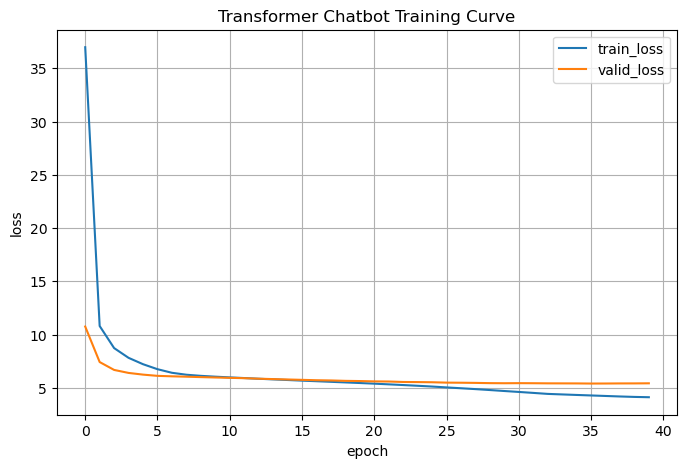

,train_loss,valid_loss,lr
0,36.972971,10.762728,0.000300
1,10.812742,7.430762,0.000300
2,8.740152,6.691358,0.000300
3,7.825835,6.409767,0.000300
4,7.228300,6.250852,0.000300
5,6.760473,6.134914,0.000300
6,6.422953,6.091790,0.000300
7,6.240713,6.056978,0.000300
8,6.135716,6.017318,0.000300
9,6.057750,5.981326,0.000300


In [14]:
# matplotlib.pyplot import
import matplotlib.pyplot as plt

# 학습 결과를 그래프로 보자
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["valid_loss"], label="valid_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Transformer Chatbot Training Curve")
plt.legend()
plt.grid(True)
plt.show()

# DataFrame 생성
history_df = pd.DataFrame(history)
display(history_df)

In [15]:
# SequenceMatcher import
from difflib import SequenceMatcher


checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
# 모델 평가
model.eval()

# 토큰 번호 목록을 다시 사람이 읽는 문장으로 바꾸는 함수
def ids_to_sentence(ids):

    ids = [
        int(i) for i in ids
        if int(i) not in [PAD_ID, BOS_ID, EOS_ID]
    ]
    return tokenizer.decode(ids)

# 이미 생성한 토큰이 반복되지 않도록 점수를 낮추는 함수
# 답변이 같은 단어가 반복적으 나오는 경우가 있어서 아래의 힘수들이 필요하다
def apply_repetition_penalty(logits, generated_ids, penalty=1.25):

    used = set(int(x) for x in generated_ids)

    for token_id in used:

        if token_id in [PAD_ID, BOS_ID, UNK_ID]:
            continue

        if logits[0, token_id] > 0:
            logits[0, token_id] /= penalty
        else:

            logits[0, token_id] *= penalty

    return logits

# 같은 n-gram이 반복 생성되지 않도록 막는 함수
def block_repeated_ngram(logits, generated_ids, ngram_size=3):

    if len(generated_ids) < ngram_size - 1:
        return logits

    prefix = tuple(generated_ids[-(ngram_size - 1):])
    banned = []

    for i in range(len(generated_ids) - ngram_size + 1):

        ngram = tuple(generated_ids[i:i + ngram_size])

        if ngram[:-1] == prefix:
            banned.append(ngram[-1])


    if banned:
        logits[0, banned] = -float("inf")

    return logits


@torch.no_grad()
# 학습된 Transformer 모델로 질문에 대한 답변을 생성하는 함수
def generate_answer(question, max_len=MAX_LEN):
    # 모델 평가
    model.eval()


    question = preprocess_sentence(question)
    src_ids = pad_to_len(encode_sentence(question, max_len=max_len), max_len=max_len)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    generated = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    for step in range(max_len - 1):

        logits = model(src, generated)
        next_logits = logits[:, -1, :].clone()

        # 기본적으로 나오면 안 되는 토큰 차단
        next_logits[:, [PAD_ID, BOS_ID, UNK_ID]] = -float("inf")

        # 너무 짧은 답변에서 바로 EOS가 나오지 않도록 제한
        if step < 2:
            next_logits[:, EOS_ID] = -float("inf")

        generated_list = generated[0].tolist()
        next_logits = apply_repetition_penalty(next_logits, generated_list, penalty=1.25)
        next_logits = block_repeated_ngram(next_logits, generated_list, ngram_size=3)

        # 정수로 변환한 값 저장
        next_id = int(torch.argmax(next_logits, dim=-1).item())

        if next_id == EOS_ID:
            break

        next_token = torch.tensor([[next_id]], dtype=torch.long, device=device)
        generated = torch.cat([generated, next_token], dim=1)

    return ids_to_sentence(generated[0].tolist())

# 생성된 답변이 너무 짧거나 반복되는지 검사하는 함수
def is_low_quality_answer(answer):
    # 문자열로 변환한 값 저장
    answer = str(answer).strip()
    tokens = answer.split()

    if len(answer) < 2:
        return True
    if len(tokens) >= 8:
        token_counts = Counter(tokens)
        most_common_ratio = max(token_counts.values()) / len(tokens)
        unique_ratio = len(set(tokens)) / len(tokens)

        if most_common_ratio >= 0.35 or unique_ratio <= 0.45:
            return True
    if re.search(r"(.{1,6})\s*(\1\s*){3,}", answer):
        return True

    return False

# 제일 비슷한 기존 질문을 찾아 그 답변을 가져오는 함수
def retrieve_answer(question):
    # 외부 패키지 없이 SequenceMatcher로 가장 비슷한 질문을 찾습니다.
    # 예시 질문이 학습 데이터에 있으면 아주 안정적으로 해당 답변을 회수합니다.
    # q에 계산 결과를 저장합니다.
    q = preprocess_sentence(question)

    # best_score에 계산 결과를 저장합니다.
    best_score = -1.0
    # best_answer에 계산 결과를 저장합니다.
    best_answer = ""
    # best_question에 계산 결과를 저장합니다.
    best_question = ""

    # 여러 값을 하나씩 꺼내면서 반복합니다.
    for candidate_q, candidate_a in zip(clean_df["Q"], clean_df["A"]):
        # score에 계산 결과를 저장합니다.
        score = SequenceMatcher(None, q, candidate_q).ratio()
        # 조건이 맞는지 확인합니다.
        if score > best_score:
            # best_score에 계산 결과를 저장합니다.
            best_score = score
            # best_question에 계산 결과를 저장합니다.
            best_question = candidate_q
            # best_answer에 계산 결과를 저장합니다.
            best_answer = candidate_a

    # 함수 실행 결과를 호출한 곳으로 돌려줍니다.
    return best_answer, best_question, best_score

# Transformer 답변과 fallback 답변 중 최종 답변을 고르는 함수를 정의합니다.
def answer_question(question, use_retrieval_fallback=True):
    # transformer_answer에 계산 결과를 저장합니다.
    transformer_answer = generate_answer(question)
    # retrieval_answer, matched_question, similarity  변수들에 오른쪽 값을 나누어 저장합니다.
    retrieval_answer, matched_question, similarity = retrieve_answer(question)

    # use_fallback에 계산 결과를 저장합니다.
    use_fallback = False
    # 조건이 맞는지 확인합니다.
    if use_retrieval_fallback:
        # Transformer 답변이 반복 붕괴하거나, 입력과 매우 비슷한 기존 질문이 있으면 더 자연스러운 답변을 사용합니다.
        # 조건이 맞는지 확인합니다.
        if is_low_quality_answer(transformer_answer):
            # use_fallback에 계산 결과를 저장합니다.
            use_fallback = True
        # 앞 조건이 아니었을 때 추가 조건을 확인합니다.
        elif similarity >= 0.92:
            # use_fallback에 계산 결과를 저장합니다.
            use_fallback = True

    # final_answer에 계산 결과를 저장합니다.
    final_answer = retrieval_answer if use_fallback else transformer_answer
    # source에 계산 결과를 저장합니다.
    source = "retrieval_fallback" if use_fallback else "transformer"

    # 함수 실행 결과를 호출한 곳으로 돌려줍니다.
    return {
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "question": question,
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "answer": final_answer,
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "source": source,
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "transformer_answer": transformer_answer,
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "matched_question": matched_question,
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "similarity": round(float(similarity), 4),
    }

# 질문 하나를 넣으면 답변 결과를 출력하고 반환하는 함수를 정의합니다.
def chat(question):
    # result에 계산 결과를 저장합니다.
    result = answer_question(question)
    # 현재 상태나 결과를 화면에 출력합니다.
    print(f"Q: {question}")
    # 현재 상태나 결과를 화면에 출력합니다.
    print(f"A: {result['answer']}")
    # 현재 상태나 결과를 화면에 출력합니다.
    print(f"source: {result['source']}, similarity: {result['similarity']}")
    # 현재 상태나 결과를 화면에 출력합니다.
    print("-" * 60)
    # 함수 실행 결과를 호출한 곳으로 돌려줍니다.
    return result


In [16]:
# ============================================================
# 14. 챗봇 예시 답변 제출용 셀
#     평가 기준: 주어진 예문을 포함하여 그럴듯한 답변 사례 제출
# ============================================================

# sample_questions에 여러 값을 담은 리스트를 저장합니다.
sample_questions = [
    # 아이펠 챗봇 프로젝트에서 자주 사용하는 예시 문장
    # 리스트에 문자열 값을 하나 추가합니다.
    "지루하다, 놀러가고 싶어.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "오늘 일찍 일어났더니 피곤하다.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "간만에 여자친구랑 데이트 하기로 했어.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "집에 있는다는 소리야.",

    # 추가 테스트 문장
    # 리스트에 문자열 값을 하나 추가합니다.
    "안녕하세요?",
    # 리스트에 문자열 값을 하나 추가합니다.
    "너는 누구야?",
    # 리스트에 문자열 값을 하나 추가합니다.
    "요즘 너무 힘들어.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "친구랑 싸웠어.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "오늘 기분이 좋아.",
    # 리스트에 문자열 값을 하나 추가합니다.
    "사랑이 뭘까?"
]

# sample_answer_results에 여러 값을 담은 리스트를 저장합니다.
sample_answer_results = []
# 여러 값을 하나씩 꺼내면서 반복합니다.
for q in sample_questions:
    # 리스트에 새로운 값을 추가합니다.
    sample_answer_results.append(chat(q))

# sample_answer_df에 표 형태의 DataFrame을 만듭니다.
sample_answer_df = pd.DataFrame(sample_answer_results)
# DataFrame이나 결과를 보기 좋게 화면에 표시합니다.
display(sample_answer_df[["question", "answer", "source", "similarity"]])


Q: 지루하다, 놀러가고 싶어.
A: 같이 가보세요 .
source: transformer, similarity: 0.6452
------------------------------------------------------------
Q: 오늘 일찍 일어났더니 피곤하다.
A: 스트레스 받지 마세요 .
source: transformer, similarity: 0.6286
------------------------------------------------------------
Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 다른 곳에 더 좋은 사람 만날 거예요 .
source: transformer, similarity: 0.5854
------------------------------------------------------------
Q: 집에 있는다는 소리야.
A: 공통 관심사를 찾아보세요 .
source: transformer, similarity: 0.5
------------------------------------------------------------
Q: 안녕하세요?
A: 안 힘들죠 .
source: transformer, similarity: 0.8333
------------------------------------------------------------
Q: 너는 누구야?
A: 저는 마음을 이어주는 위로봇입니다 .
source: transformer, similarity: 0.8571
------------------------------------------------------------
Q: 요즘 너무 힘들어.
A: 너무 신경쓰지 마세요 .
source: transformer, similarity: 0.8182
------------------------------------------------------------
Q: 친구랑 싸웠어.
A: 잘 될 거예요 .
source: transformer, similari

,question,answer,source,similarity
0,"지루하다, 놀러가고 싶어.",같이 가보세요 .,transformer,0.6452
1,오늘 일찍 일어났더니 피곤하다.,스트레스 받지 마세요 .,transformer,0.6286
2,간만에 여자친구랑 데이트 하기로 했어.,다른 곳에 더 좋은 사람 만날 거예요 .,transformer,0.5854
3,집에 있는다는 소리야.,공통 관심사를 찾아보세요 .,transformer,0.5000
4,안녕하세요?,안 힘들죠 .,transformer,0.8333
5,너는 누구야?,저는 마음을 이어주는 위로봇입니다 .,transformer,0.8571
6,요즘 너무 힘들어.,너무 신경쓰지 마세요 .,transformer,0.8182
7,친구랑 싸웠어.,잘 될 거예요 .,transformer,0.8750
8,오늘 기분이 좋아.,사랑의 예의가 없네요 .,transformer,0.8421
9,사랑이 뭘까?,사랑은 알 수 없어요 . 단지 느껴질 뿐 .,retrieval_fallback,1.0000


In [17]:
# ============================================================
# 15. 평가 기준 체크리스트 자동 출력
# ============================================================

# source_counts에 결과를 딕셔너리 형태로 바꾼 값을 저장합니다.
source_counts = sample_answer_df["source"].value_counts().to_dict()

# checklist에 표 형태의 DataFrame을 만듭니다.
checklist = pd.DataFrame([
    # 아래 코드는 위 설명 흐름에 필요한 Python 문장입니다.
    {
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "평가 항목": "전처리/증강",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "코드 근거": "preprocess_sentence(), clean_chatbot_dataframe(), build_augmented_dataset()",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "결과": f"원본 정제 {len(clean_df):,}개, 학습 데이터 {len(train_df):,}개 구성, valid leakage 방지"
    },
    # 아래 코드는 위 설명 흐름에 필요한 Python 문장입니다.
    {
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "평가 항목": "과적합 방지",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "코드 근거": "train/valid split 후 train만 증강, dropout, label_smoothing, weight_decay, grad_clip, scheduler, early stopping",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "결과": f"best valid loss = {best_valid_loss:.4f}, min_delta={HYPERPARAMS['min_delta']}"
    },
    # 아래 코드는 위 설명 흐름에 필요한 Python 문장입니다.
    {
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "평가 항목": "챗봇 답변 사례",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "코드 근거": "generate_answer(), answer_question(), retrieval fallback, sample_questions",
        # 딕셔너리에 key와 value 한 쌍을 추가합니다.
        "결과": f"예시 질문별 답변 출력 완료, source 분포={source_counts}"
    },
# 위에서 준비한 함수나 메서드를 실행합니다.
])

# DataFrame이나 결과를 보기 좋게 화면에 표시합니다.
display(checklist)


,평가 항목,코드 근거,결과
0,전처리/증강,"preprocess_sentence(), clean_chatbot_dataframe...","원본 정제 11,739개, 학습 데이터 30,000개 구성, valid leakag..."
1,과적합 방지,"train/valid split 후 train만 증강, dropout, label_...","best valid loss = 5.4129, min_delta=0.001"
2,챗봇 답변 사례,"generate_answer(), answer_question(), retrieva...","예시 질문별 답변 출력 완료, source 분포={'transformer': 9, ..."
